Import Required Libraries

In [3]:
# ==========================================================
# AppointmentBot AI : Smart Appointment Assistant
# Part 1 : Import Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import re
import string
import nltk

# Download NLTK Resources
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Load Dataset

In [4]:
# Load Dataset

df = pd.read_csv("appointment_booking_dataset.csv")

In [5]:
df.head()

,Message,Label
0,Please book my appointment with the orthopedic...,Booking
1,Good morning.,Non-Booking
2,Hello.,Non-Booking
3,Book a consultation for tomorrow.,Booking
4,Where is your clinic located?,Non-Booking


Display Dataset Shape

In [6]:
print("Dataset Shape :", df.shape)

Dataset Shape : (10000, 2)


Display Column Names

In [7]:
print(df.columns)

Index(['Message', 'Label'], dtype='object')


Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Message  10000 non-null  object
 1   Label    10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


Check Missing Values

In [9]:
df.isnull().sum()

,0
Message,0
Label,0


Check Duplicate Records

In [10]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 9809


In [11]:
df = df.drop_duplicates()

In [12]:
print("Shape After Removing Duplicates :", df.shape)

Shape After Removing Duplicates : (191, 2)


Display Random Records

Display random messages to better understand the dataset.

In [13]:
df.sample(10)

,Message,Label
3116,I would like to meet the doctor on Friday.,Booking
174,Please book my appointment with the eye specia...,Booking
1550,I would like to meet the pediatrician on tomor...,Booking
1255,I would like to meet the dentist on tomorrow.,Booking
28,Is there an appointment available on Friday?,Booking
41,Can you schedule my checkup on Saturday?,Booking
2542,I would like to meet the doctor on Wednesday.,Booking
2640,I would like to meet the neurologist on next M...,Booking
338,I would like to meet the orthopedic specialist...,Booking
430,Can I schedule a visit on Monday?,Booking


Class Distribution

Check the number of Booking and Non-Booking messages

In [14]:
df['Label'].value_counts()

,count
Label,
Booking,181
Non-Booking,10


Count Plot

Visualize Booking and Non-Booking messages.

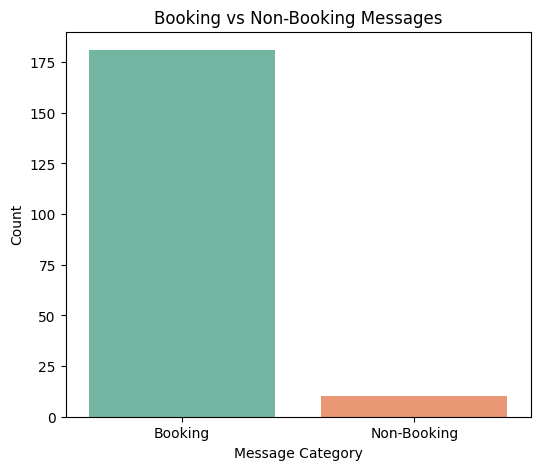

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Label',
    palette='Set2'
)

plt.title("Booking vs Non-Booking Messages")

plt.xlabel("Message Category")

plt.ylabel("Count")

plt.show()

Pie Chart

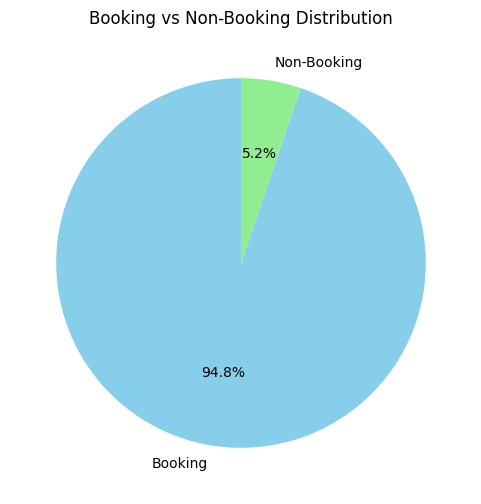

In [16]:
plt.figure(figsize=(6,6))

df['Label'].value_counts().plot(

    kind='pie',

    autopct='%1.1f%%',

    colors=['skyblue','lightgreen'],

    startangle=90

)

plt.ylabel("")

plt.title("Booking vs Non-Booking Distribution")

plt.show()

Message Length

In [17]:
df['Message_Length'] = df['Message'].apply(len)

In [18]:
df[['Message','Message_Length']].head()

,Message,Message_Length
0,Please book my appointment with the orthopedic...,58
1,Good morning.,13
2,Hello.,6
3,Book a consultation for tomorrow.,33
4,Where is your clinic located?,29


Message Length Statistics

In [19]:
df['Message_Length'].describe()

,Message_Length
count,191.000000
mean,45.120419
std,8.305430
min,6.000000
25%,41.000000
50%,46.000000
75%,50.500000
max,63.000000


Histogram

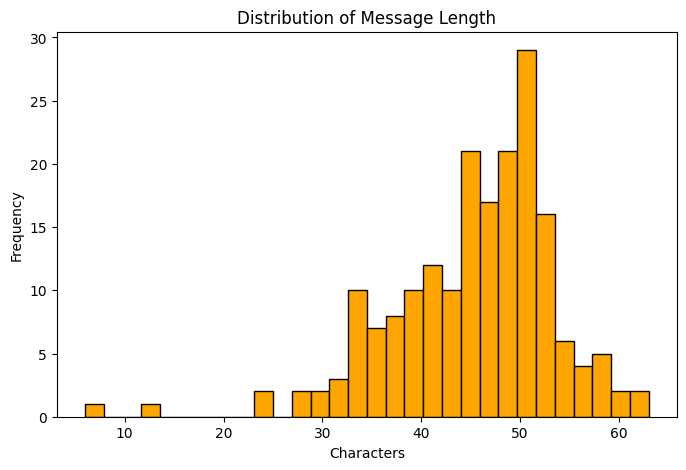

In [20]:
plt.figure(figsize=(8,5))

plt.hist(

    df['Message_Length'],

    bins=30,

    color='orange',

    edgecolor='black'

)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

Booking vs Non-Booking Message Length

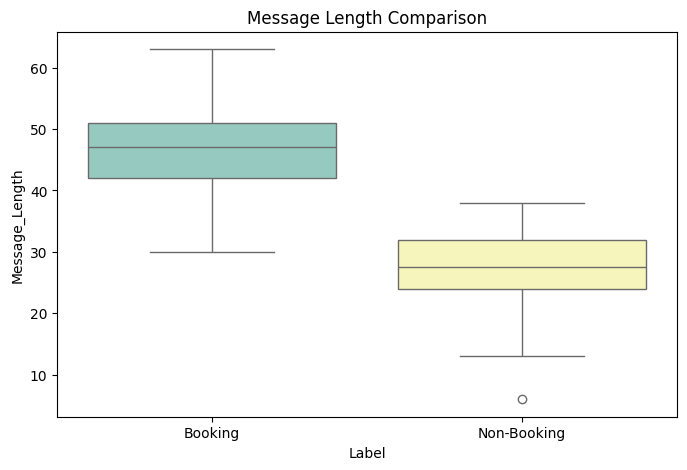

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=df,

    x='Label',

    y='Message_Length',

    palette='Set3'

)

plt.title("Message Length Comparison")

plt.show()

Summary

In [22]:
print("="*60)

print("Dataset Summary")

print("="*60)

print("Total Records :", len(df))

print("Total Columns :", len(df.columns))

print()

print(df['Label'].value_counts())

print("="*60)

Dataset Summary
Total Records : 191
Total Columns : 3

Label
Booking        181
Non-Booking     10
Name: count, dtype: int64


**Text Preprocessing and NLP**

In [23]:
# Install WordCloud (Run only once)
!pip install wordcloud

In [24]:
from wordcloud import WordCloud

Display Original Messages

In [25]:
df[['Message']].head(10)

,Message
0,Please book my appointment with the orthopedic...
1,Good morning.
2,Hello.
3,Book a consultation for tomorrow.
4,Where is your clinic located?
5,Do you accept insurance?
6,I have a question about your services.
7,Can you schedule my checkup on Monday?
11,I want to book an appointment for Friday.
12,Can you schedule my checkup on tomorrow?


Create Stopwords and Stemmer

In [26]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

Create Preprocessing Function

In [27]:
def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    # Join words
    return " ".join(words)

Apply Preprocessing

In [28]:
df['Clean_Text'] = df['Message'].apply(preprocess)

In [29]:
df[['Message','Clean_Text']].head(10)

,Message,Clean_Text
0,Please book my appointment with the orthopedic...,pleas book appoint orthoped specialist
1,Good morning.,good morn
2,Hello.,hello
3,Book a consultation for tomorrow.,book consult tomorrow
4,Where is your clinic located?,clinic locat
5,Do you accept insurance?,accept insur
6,I have a question about your services.,question servic
7,Can you schedule my checkup on Monday?,schedul checkup monday
11,I want to book an appointment for Friday.,want book appoint friday
12,Can you schedule my checkup on tomorrow?,schedul checkup tomorrow


Check Missing Values

In [30]:
df['Clean_Text'].isnull().sum()

np.int64(0)

Calculate Word Count

Find the number of words in each cleaned message.

In [31]:
df['Word_Count'] = df['Clean_Text'].apply(lambda x: len(x.split()))

In [32]:
df[['Clean_Text','Word_Count']].head()

,Clean_Text,Word_Count
0,pleas book appoint orthoped specialist,5
1,good morn,2
2,hello,1
3,book consult tomorrow,3
4,clinic locat,2


Word Count Statistics

Display descriptive statistics for the cleaned text.

In [33]:
df['Word_Count'].describe()

,Word_Count
count,191.000000
mean,4.570681
std,1.249833
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,7.000000


Histogram of Word Count

Visualize the distribution of words per message.

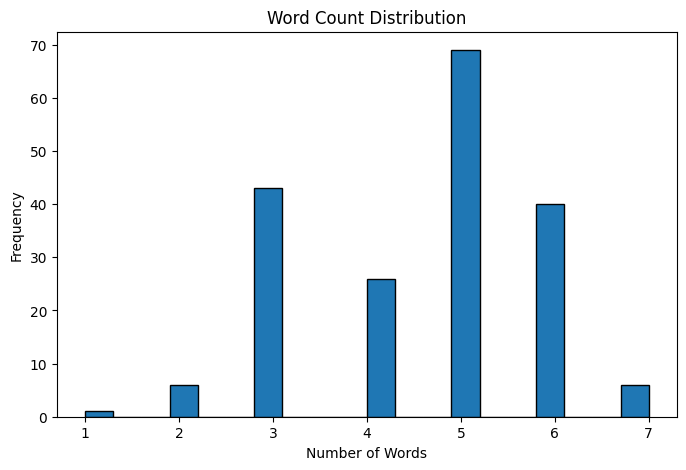

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Word_Count'],
    bins=20,
    edgecolor='black'
)

plt.title("Word Count Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

Booking Word Cloud

Generate a Word Cloud for Booking messages

In [35]:
booking_text = " ".join(

    df[df['Label']=="Booking"]['Clean_Text']

)

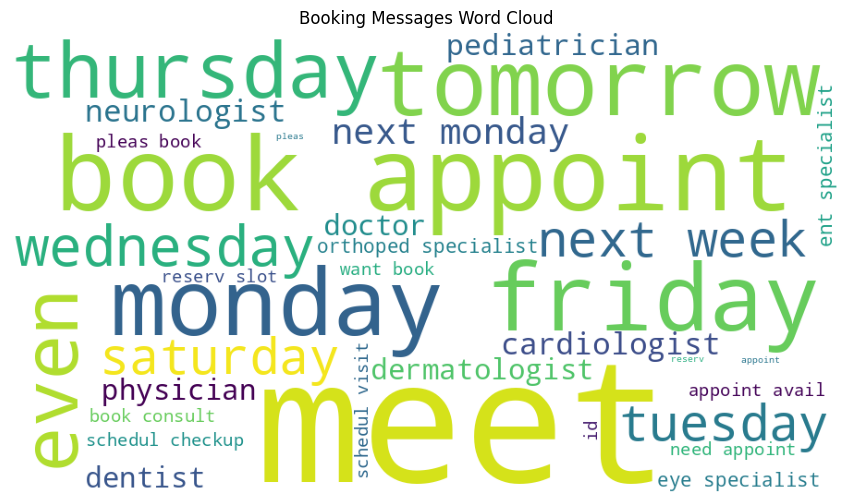

In [36]:
wordcloud = WordCloud(

    width=900,
    height=500,
    background_color='white'

).generate(booking_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Booking Messages Word Cloud")

plt.show()

Non-Booking Word Cloud

Generate a Word Cloud for Non-Booking messages.

In [37]:
non_booking_text = " ".join(

    df[df['Label']=="Non-Booking"]['Clean_Text']

)

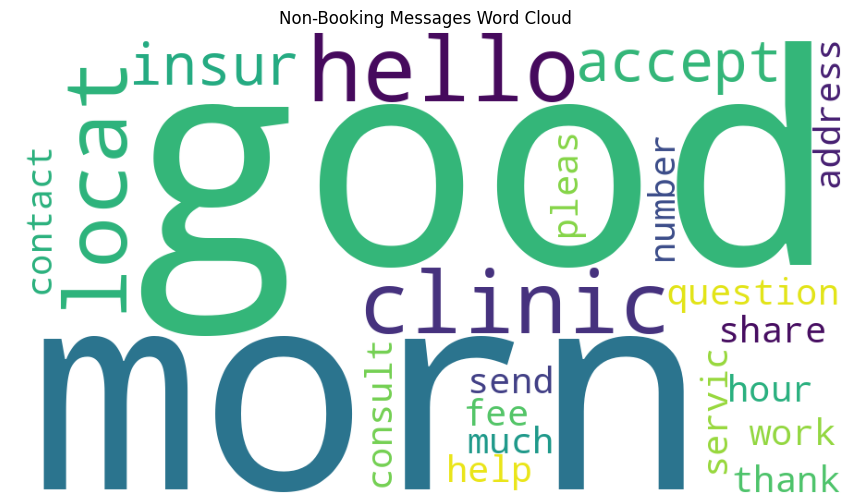

In [38]:
wordcloud = WordCloud(

    width=900,
    height=500,
    background_color='white'

).generate(non_booking_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Non-Booking Messages Word Cloud")

plt.show()

Most Frequent Words


Count the frequency of words in all messages.

In [39]:
from collections import Counter

In [40]:
all_words = " ".join(df['Clean_Text']).split()

word_frequency = Counter(all_words)

In [41]:
word_frequency.most_common(20)

[('like', 110),
 ('would', 100),
 ('meet', 100),
 ('appoint', 41),
 ('specialist', 36),
 ('monday', 32),
 ('next', 32),
 ('book', 30),
 ('schedul', 20),
 ('tomorrow', 16),
 ('friday', 16),
 ('thursday', 16),
 ('even', 16),
 ('week', 16),
 ('wednesday', 16),
 ('saturday', 16),
 ('tuesday', 16),
 ('pleas', 12),
 ('orthoped', 12),
 ('neurologist', 12)]

Top 20 Frequent Words

Display the most common words.

In [42]:
top_words = pd.DataFrame(

    word_frequency.most_common(20),

    columns=['Word','Frequency']

)

top_words

,Word,Frequency
0,like,110
1,would,100
2,meet,100
3,appoint,41
4,specialist,36
5,monday,32
6,next,32
7,book,30
8,schedul,20
9,tomorrow,16


Visualize Top Words

Plot the 20 most frequent words.

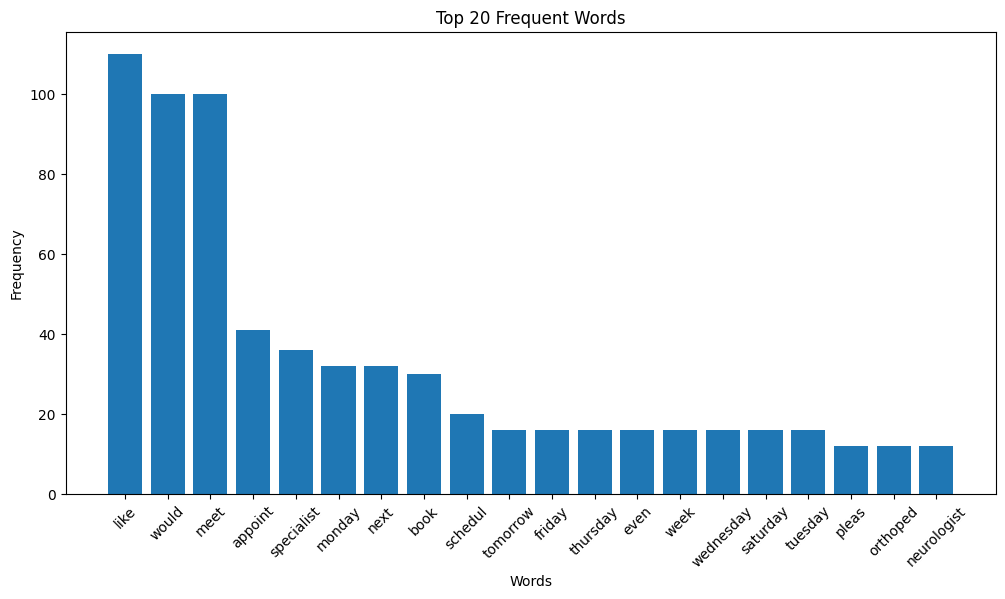

In [43]:
plt.figure(figsize=(12,6))

plt.bar(

    top_words['Word'],

    top_words['Frequency']

)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

Booking Messages Only

Display a few Booking messages after preprocessing.

In [44]:
df[df['Label']=="Booking"][
    ['Message','Clean_Text']
].head(10)

,Message,Clean_Text
0,Please book my appointment with the orthopedic...,pleas book appoint orthoped specialist
3,Book a consultation for tomorrow.,book consult tomorrow
7,Can you schedule my checkup on Monday?,schedul checkup monday
11,I want to book an appointment for Friday.,want book appoint friday
12,Can you schedule my checkup on tomorrow?,schedul checkup tomorrow
13,Please reserve my appointment.,pleas reserv appoint
15,Is there an appointment available on Thursday?,appoint avail thursday
19,Is there an appointment available on this even...,appoint avail even
22,Need an appointment with the neurologist.,need appoint neurologist
23,Is there an appointment available on tomorrow?,appoint avail tomorrow


Non-Booking Messages Only

Display a few Non-Booking messages after preprocessing.

In [45]:
df[df['Label']=="Non-Booking"][
    ['Message','Clean_Text']
].head(10)

,Message,Clean_Text
1,Good morning.,good morn
2,Hello.,hello
4,Where is your clinic located?,clinic locat
5,Do you accept insurance?,accept insur
6,I have a question about your services.,question servic
21,Can you share your contact number?,share contact number
29,What are your working hours?,work hour
35,How much is the consultation fee?,much consult fee
51,Thank you for your help.,thank help
79,Please send me the address.,pleas send address


Save Preprocessed Dataset

Save the cleaned dataset for future use.

In [46]:
df.to_csv(

    "appointment_booking_cleaned_dataset.csv",

    index=False

)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


Display Final Dataset

Display the first few rows of the final dataset.

In [47]:
df.head()

,Message,Label,Message_Length,Clean_Text,Word_Count
0,Please book my appointment with the orthopedic...,Booking,58,pleas book appoint orthoped specialist,5
1,Good morning.,Non-Booking,13,good morn,2
2,Hello.,Non-Booking,6,hello,1
3,Book a consultation for tomorrow.,Booking,33,book consult tomorrow,3
4,Where is your clinic located?,Non-Booking,29,clinic locat,2


Summary

Print a summary after preprocessing.

In [48]:
print("="*60)

print("Text Preprocessing Completed Successfully")

print("="*60)

print("Total Records :",len(df))

print("Total Features :",len(df.columns))

print()

print(df.head())

print("="*60)

Text Preprocessing Completed Successfully
Total Records : 191
Total Features : 5

                                             Message        Label  \
0  Please book my appointment with the orthopedic...      Booking   
1                                      Good morning.  Non-Booking   
2                                             Hello.  Non-Booking   
3                  Book a consultation for tomorrow.      Booking   
4                      Where is your clinic located?  Non-Booking   

   Message_Length                              Clean_Text  Word_Count  
0              58  pleas book appoint orthoped specialist           5  
1              13                               good morn           2  
2               6                                   hello           1  
3              33                   book consult tomorrow           3  
4              29                            clinic locat           2  


**Feature Extraction and Model Training**

Feature and Target Selection

Separate the independent feature (Clean_Text) and target variable (Label)

In [49]:
# ============================================
# Feature and Target
# ============================================

X = df['Clean_Text']

y = df['Label']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (191,)
Target Shape : (191,)


Train-Test Split

In [50]:
# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 152
Testing Samples : 39


Feature Extraction Using CountVectorizer

In [51]:
# ============================================
# CountVectorizer
# ============================================

cv = CountVectorizer()

Fit training data

In [52]:
X_train_cv = cv.fit_transform(X_train)

Transform testing data

In [53]:
X_test_cv = cv.transform(X_test)

Display Shape

In [54]:
print("Training Matrix Shape :", X_train_cv.shape)

print("Testing Matrix Shape :", X_test_cv.shape)

Training Matrix Shape : (152, 52)
Testing Matrix Shape : (39, 52)


Display Vocabulary Size


Display total number of unique words learned.

In [55]:
print("Vocabulary Size :", len(cv.vocabulary_))

Vocabulary Size : 52


Display Sample Vocabulary


Display first 20 words.

In [56]:
list(cv.vocabulary_.keys())[:20]

['would',
 'like',
 'meet',
 'orthoped',
 'specialist',
 'tuesday',
 'book',
 'consult',
 'next',
 'week',
 'ent',
 'even',
 'id',
 'reserv',
 'slot',
 'thursday',
 'want',
 'appoint',
 'wednesday',
 'doctor']

MODEL 1
CountVectorizer + Multinomial Naive Bayes

Train Naive Bayes Model


Multinomial Naive Bayes is one of the most popular algorithms for text classification.

In [57]:
# ============================================
# Multinomial Naive Bayes
# ============================================

nb_model = MultinomialNB()

nb_model.fit(X_train_cv, y_train)

MultinomialNB()

Prediction

In [58]:
nb_prediction = nb_model.predict(X_test_cv)

Accuracy

In [59]:
nb_accuracy = accuracy_score(y_test, nb_prediction)

print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.9487179487179487


Classification Report

In [60]:
print(classification_report(y_test, nb_prediction))

              precision    recall  f1-score   support

     Booking       0.95      1.00      0.97        37
 Non-Booking       0.00      0.00      0.00         2

    accuracy                           0.95        39
   macro avg       0.47      0.50      0.49        39
weighted avg       0.90      0.95      0.92        39



Confusion Matrix

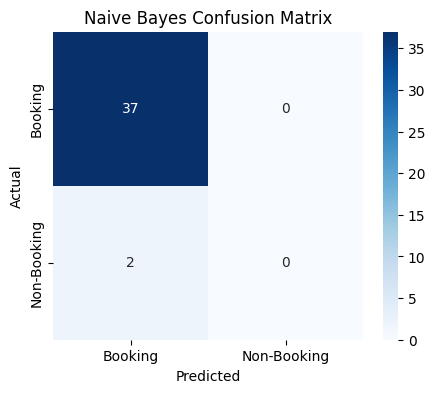

In [61]:
cm = confusion_matrix(y_test, nb_prediction)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=['Booking','Non-Booking'],

    yticklabels=['Booking','Non-Booking']

)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

MODEL 2
CountVectorizer + Logistic Regression

Train Logistic Regression


Logistic Regression performs well for binary text classification problems.

In [62]:
lr_model = LogisticRegression(

    max_iter=1000

)

lr_model.fit(

    X_train_cv,

    y_train

)

LogisticRegression(max_iter=1000)

Prediction

In [63]:
lr_prediction = lr_model.predict(X_test_cv)

Accuracy

In [64]:
lr_accuracy = accuracy_score(

    y_test,

    lr_prediction

)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.9487179487179487


Classification Report

In [65]:
print(classification_report(

    y_test,

    lr_prediction

))

              precision    recall  f1-score   support

     Booking       0.95      1.00      0.97        37
 Non-Booking       0.00      0.00      0.00         2

    accuracy                           0.95        39
   macro avg       0.47      0.50      0.49        39
weighted avg       0.90      0.95      0.92        39



Confusion Matrix

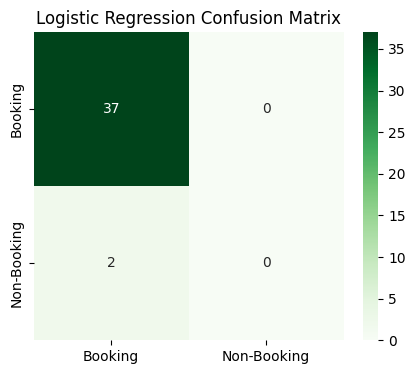

In [66]:
cm = confusion_matrix(

    y_test,

    lr_prediction

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Greens',

    xticklabels=['Booking','Non-Booking'],

    yticklabels=['Booking','Non-Booking']

)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

MODEL 3
CountVectorizer + Linear SVM

Train Linear SVM

Linear SVM is one of the highest-performing algorithms for NLP classification.

In [67]:
svm_model = LinearSVC()

svm_model.fit(

    X_train_cv,

    y_train

)

LinearSVC()

Prediction

In [68]:
svm_prediction = svm_model.predict(

    X_test_cv

)

Accuracy

In [69]:
svm_accuracy = accuracy_score(

    y_test,

    svm_prediction

)

print("Linear SVM Accuracy :", svm_accuracy)

Linear SVM Accuracy : 0.9743589743589743


Classification Report

In [70]:
print(classification_report(

    y_test,

    svm_prediction

))

              precision    recall  f1-score   support

     Booking       0.97      1.00      0.99        37
 Non-Booking       1.00      0.50      0.67         2

    accuracy                           0.97        39
   macro avg       0.99      0.75      0.83        39
weighted avg       0.98      0.97      0.97        39



Confusion Matrix

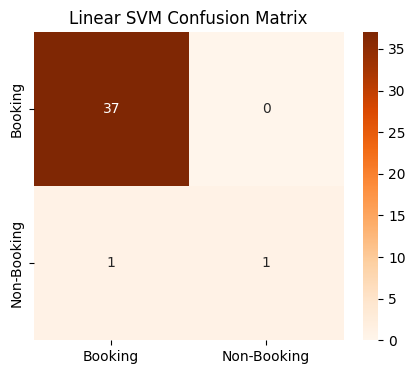

In [71]:
cm = confusion_matrix(

    y_test,

    svm_prediction

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Oranges',

    xticklabels=['Booking','Non-Booking'],

    yticklabels=['Booking','Non-Booking']

)

plt.title("Linear SVM Confusion Matrix")

plt.show()

Compare Model Accuracy

Compare the performance of all three CountVectorizer models.

In [73]:
comparison = pd.DataFrame({

    "Model":[

        "CountVectorizer + Naive Bayes",

        "CountVectorizer + Logistic Regression",

        "CountVectorizer + Linear SVM"

    ],

    "Accuracy":[

        nb_accuracy,

        lr_accuracy,

        svm_accuracy

    ]

})

comparison

,Model,Accuracy
0,CountVectorizer + Naive Bayes,0.948718
1,CountVectorizer + Logistic Regression,0.948718
2,CountVectorizer + Linear SVM,0.974359


Accuracy Bar Chart

Visualize model accuracy.

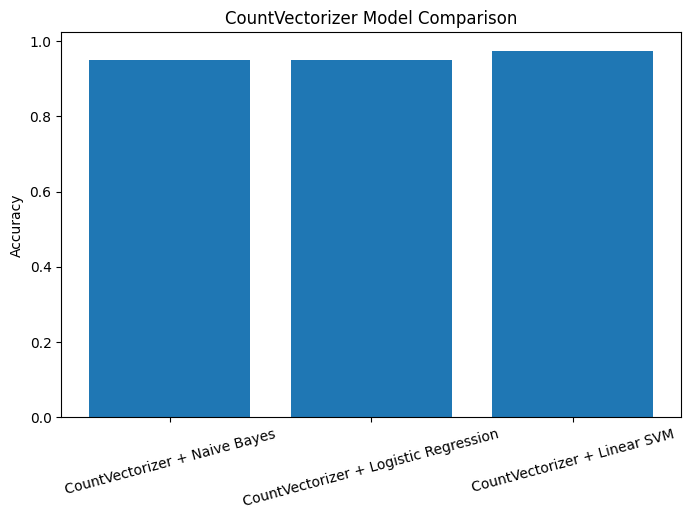

In [74]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison['Model'],

    comparison['Accuracy']

)

plt.xticks(rotation=15)

plt.ylabel("Accuracy")

plt.title("CountVectorizer Model Comparison")

plt.show()

Best Model

Identify the best-performing CountVectorizer model.

In [75]:
best_model = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

best_model

,Model,Accuracy
2,CountVectorizer + Linear SVM,0.974359
0,CountVectorizer + Naive Bayes,0.948718
1,CountVectorizer + Logistic Regression,0.948718


Test the Best Model


Predict the intent of a new customer message.

In [76]:
new_message = [

    "Can I schedule an appointment for tomorrow?"

]

Preprocess

In [77]:
clean = [preprocess(text) for text in new_message]

Vectorize

In [78]:
vector = cv.transform(clean)

Prediction

In [79]:
prediction = svm_model.predict(vector)

print("Prediction :", prediction[0])

Prediction : Booking


Another Test

In [80]:
new_message = [

    "Thank you for your support"

]

clean = [preprocess(text) for text in new_message]

vector = cv.transform(clean)

prediction = svm_model.predict(vector)

print("Prediction :", prediction[0])

Prediction : Non-Booking


Feature Extraction Using TF-IDF

Convert the cleaned text into TF-IDF vectors.

In [83]:
# ==========================================================
# Feature Extraction Using TF-IDF
# ==========================================================

tfidf = TfidfVectorizer()

Fit the training data.

In [87]:

X_train_tfidf = tfidf.fit_transform(X_train)

Transform the testing data.

In [88]:
X_test_tfidf = tfidf.transform(X_test)

Display matrix size.

In [89]:
print("Training Matrix Shape :", X_train_tfidf.shape)

print("Testing Matrix Shape :", X_test_tfidf.shape)

Training Matrix Shape : (152, 52)
Testing Matrix Shape : (39, 52)


Display Vocabulary Size


Display the total number of unique words learned by the TF-IDF vectorizer.

In [90]:
print("Vocabulary Size :", len(tfidf.vocabulary_))

Vocabulary Size : 52


Display Sample Vocabulary

In [91]:
list(tfidf.vocabulary_.keys())[:20]

['would',
 'like',
 'meet',
 'orthoped',
 'specialist',
 'tuesday',
 'book',
 'consult',
 'next',
 'week',
 'ent',
 'even',
 'id',
 'reserv',
 'slot',
 'thursday',
 'want',
 'appoint',
 'wednesday',
 'doctor']

Model 1

TF-IDF + Multinomial Naive Bayes

In [ ]:
Train the Model


Train the Multinomial Naive Bayes model using TF-IDF features.

In [92]:
tfidf_nb = MultinomialNB()

tfidf_nb.fit(

    X_train_tfidf,

    y_train

)

MultinomialNB()

Prediction

In [93]:
tfidf_nb_prediction = tfidf_nb.predict(

    X_test_tfidf

)

Accuracy

In [94]:
tfidf_nb_accuracy = accuracy_score(

    y_test,

    tfidf_nb_prediction

)

print("TF-IDF + Naive Bayes Accuracy :", tfidf_nb_accuracy)

TF-IDF + Naive Bayes Accuracy : 0.9487179487179487


Classification Report

In [95]:
print(classification_report(

    y_test,

    tfidf_nb_prediction

))

              precision    recall  f1-score   support

     Booking       0.95      1.00      0.97        37
 Non-Booking       0.00      0.00      0.00         2

    accuracy                           0.95        39
   macro avg       0.47      0.50      0.49        39
weighted avg       0.90      0.95      0.92        39





Confusion Matrix


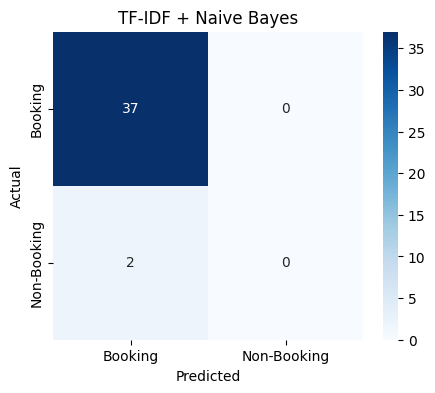

In [96]:
cm = confusion_matrix(

    y_test,

    tfidf_nb_prediction

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=['Booking','Non-Booking'],

    yticklabels=['Booking','Non-Booking']

)

plt.title("TF-IDF + Naive Bayes")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Model 2

TF-IDF + Logistic Regression

Train the Model

In [97]:
tfidf_lr = LogisticRegression(

    max_iter=1000

)

tfidf_lr.fit(

    X_train_tfidf,

    y_train

)

LogisticRegression(max_iter=1000)

Prediction

In [98]:
tfidf_lr_prediction = tfidf_lr.predict(

    X_test_tfidf

)

Accuracy

In [99]:
tfidf_lr_accuracy = accuracy_score(

    y_test,

    tfidf_lr_prediction

)

print("TF-IDF + Logistic Regression Accuracy :", tfidf_lr_accuracy)

TF-IDF + Logistic Regression Accuracy : 0.9487179487179487


Classification Report

In [100]:
print(classification_report(

    y_test,

    tfidf_lr_prediction

))

              precision    recall  f1-score   support

     Booking       0.95      1.00      0.97        37
 Non-Booking       0.00      0.00      0.00         2

    accuracy                           0.95        39
   macro avg       0.47      0.50      0.49        39
weighted avg       0.90      0.95      0.92        39



Confusion Matrix

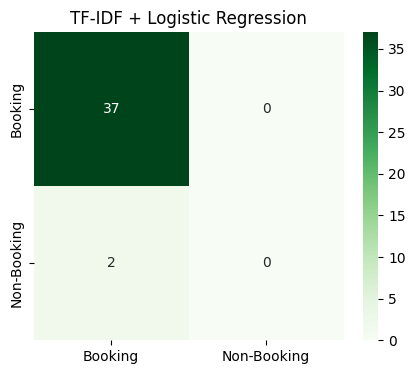

In [101]:
cm = confusion_matrix(

    y_test,

    tfidf_lr_prediction

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Greens',

    xticklabels=['Booking','Non-Booking'],

    yticklabels=['Booking','Non-Booking']

)

plt.title("TF-IDF + Logistic Regression")

plt.show()

Model 3
TF-IDF + Linear SVM

Train the Model

In [102]:
tfidf_svm = LinearSVC()

tfidf_svm.fit(

    X_train_tfidf,

    y_train

)

LinearSVC()

Prediction

In [103]:
tfidf_svm_prediction = tfidf_svm.predict(

    X_test_tfidf

)

Accuracy

In [104]:
tfidf_svm_accuracy = accuracy_score(

    y_test,

    tfidf_svm_prediction

)

print("TF-IDF + Linear SVM Accuracy :", tfidf_svm_accuracy)

TF-IDF + Linear SVM Accuracy : 0.9487179487179487


Classification Report

In [105]:
print(classification_report(

    y_test,

    tfidf_svm_prediction

))

              precision    recall  f1-score   support

     Booking       0.95      1.00      0.97        37
 Non-Booking       0.00      0.00      0.00         2

    accuracy                           0.95        39
   macro avg       0.47      0.50      0.49        39
weighted avg       0.90      0.95      0.92        39



Confusion Matrix

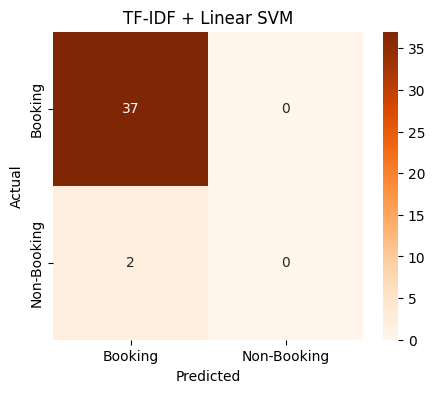

In [106]:
cm = confusion_matrix(

    y_test,

    tfidf_svm_prediction

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Oranges',

    xticklabels=['Booking','Non-Booking'],

    yticklabels=['Booking','Non-Booking']

)

plt.title("TF-IDF + Linear SVM")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Compare TF-IDF Models

Compare the accuracy of all three TF-IDF models.

In [107]:
tfidf_results = pd.DataFrame({

    "Model":[

        "TF-IDF + Naive Bayes",

        "TF-IDF + Logistic Regression",

        "TF-IDF + Linear SVM"

    ],

    "Accuracy":[

        tfidf_nb_accuracy,

        tfidf_lr_accuracy,

        tfidf_svm_accuracy

    ]

})

tfidf_results

,Model,Accuracy
0,TF-IDF + Naive Bayes,0.948718
1,TF-IDF + Logistic Regression,0.948718
2,TF-IDF + Linear SVM,0.948718


Accuracy Comparison Chart

Visualize the model accuracies.

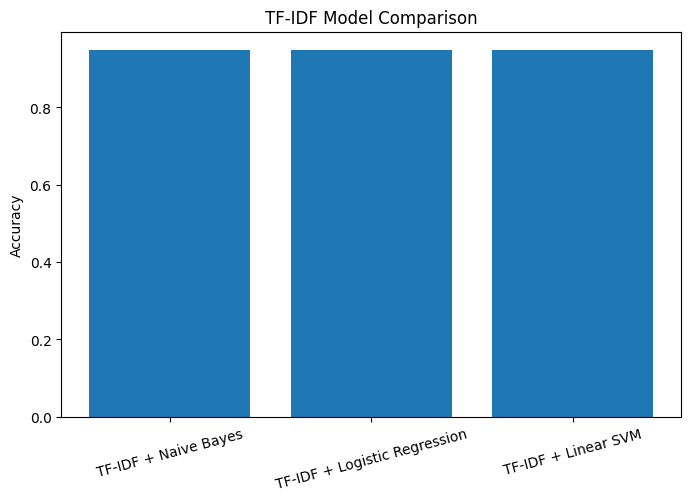

In [108]:
plt.figure(figsize=(8,5))

plt.bar(

    tfidf_results['Model'],

    tfidf_results['Accuracy']

)

plt.xticks(rotation=15)

plt.ylabel("Accuracy")

plt.title("TF-IDF Model Comparison")

plt.show()

Best TF-IDF Model

In [109]:
tfidf_results.sort_values(

    by="Accuracy",

    ascending=False

)

,Model,Accuracy
0,TF-IDF + Naive Bayes,0.948718
1,TF-IDF + Logistic Regression,0.948718
2,TF-IDF + Linear SVM,0.948718


Test the Best Model


Predict the intent of a new customer message.

In [110]:
message = [

    "Can I book an appointment for tomorrow?"

]

clean_message = [preprocess(text) for text in message]

vector = tfidf.transform(clean_message)

prediction = tfidf_svm.predict(vector)

print("Prediction :", prediction[0])

Prediction : Booking


Another Test

In [111]:
message = [

    "Thank you for your support."

]

clean_message = [preprocess(text) for text in message]

vector = tfidf.transform(clean_message)

prediction = tfidf_svm.predict(vector)

print("Prediction :", prediction[0])

Prediction : Non-Booking


**Model Comparison, Save Model & Build AppointmentBot AI**

Import Joblib

Joblib is used to save and load trained machine learning models.

In [112]:
# ==========================================================
# Import Joblib
# ==========================================================

import joblib

Compare All Models


Create a comparison table containing the accuracy of all six models.

In [113]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model":[

        "CountVectorizer + Naive Bayes",

        "CountVectorizer + Logistic Regression",

        "CountVectorizer + Linear SVM",

        "TF-IDF + Naive Bayes",

        "TF-IDF + Logistic Regression",

        "TF-IDF + Linear SVM"

    ],

    "Accuracy":[

        nb_accuracy,

        lr_accuracy,

        svm_accuracy,

        tfidf_nb_accuracy,

        tfidf_lr_accuracy,

        tfidf_svm_accuracy

    ]

})

comparison

,Model,Accuracy
0,CountVectorizer + Naive Bayes,0.948718
1,CountVectorizer + Logistic Regression,0.948718
2,CountVectorizer + Linear SVM,0.974359
3,TF-IDF + Naive Bayes,0.948718
4,TF-IDF + Logistic Regression,0.948718
5,TF-IDF + Linear SVM,0.948718


Accuracy Comparison Chart


Visualize the accuracy of all six models.

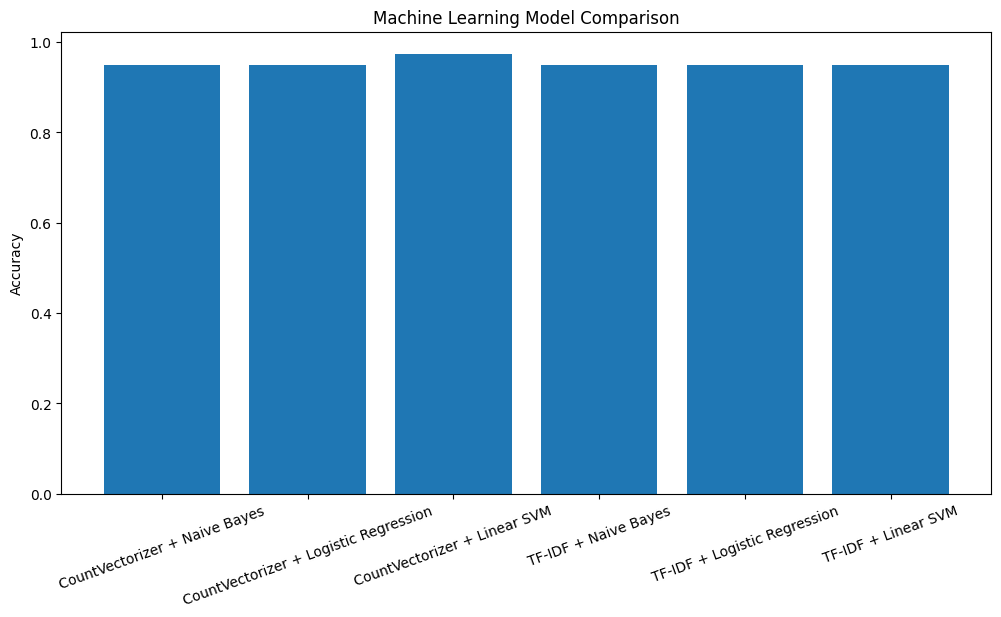

In [114]:
plt.figure(figsize=(12,6))

plt.bar(

    comparison["Model"],

    comparison["Accuracy"]

)

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Machine Learning Model Comparison")

plt.show()

Sort Models


Arrange models from highest to lowest accuracy.

In [115]:
comparison.sort_values(

    by="Accuracy",

    ascending=False

)

,Model,Accuracy
2,CountVectorizer + Linear SVM,0.974359
0,CountVectorizer + Naive Bayes,0.948718
1,CountVectorizer + Logistic Regression,0.948718
3,TF-IDF + Naive Bayes,0.948718
4,TF-IDF + Logistic Regression,0.948718
5,TF-IDF + Linear SVM,0.948718


Select Best Model

In [118]:
# ==========================================================
# Select Best Model
# ==========================================================

best_model = svm_model

best_vectorizer = cv

print("Best Model : CountVectorizer + Linear SVM")

Best Model : CountVectorizer + Linear SVM


Save Model

In [119]:
import joblib

joblib.dump(best_model, "appointment_bot_model.pkl")
joblib.dump(best_vectorizer, "count_vectorizer.pkl")

print("Model and Vectorizer Saved Successfully!")

Model and Vectorizer Saved Successfully!


Load Model

In [120]:
loaded_model = joblib.load("appointment_bot_model.pkl")
loaded_vectorizer = joblib.load("count_vectorizer.pkl")

Prediction Function

In [121]:
def predict_booking(message):

    clean = preprocess(message)

    vector = loaded_vectorizer.transform([clean])

    prediction = loaded_model.predict(vector)

    return prediction[0]

Test Message 1


Predict a booking request.

In [122]:
message = "Can I schedule an appointment for tomorrow?"

print("Message :", message)

print("Prediction :", predict_booking(message))

Message : Can I schedule an appointment for tomorrow?
Prediction : Booking


Test Message 2

In [123]:
message = "Please reserve a slot for Monday."

print("Prediction :", predict_booking(message))

Prediction : Booking


Test Message 3

In [124]:
message = "Thank you very much."

print("Prediction :", predict_booking(message))

Prediction : Non-Booking


Test Message 4

In [125]:
message = "Good Morning"

print("Prediction :", predict_booking(message))

Prediction : Non-Booking


Build AppointmentBot AI


Create a chatbot that continuously accepts user input until the user types exit.

In [126]:
# ==========================================================
# AppointmentBot AI
# ==========================================================

print("="*60)

print(" AppointmentBot AI : Smart Appointment Assistant ")

print("="*60)

print("Type 'exit' to stop the chatbot.")

print("="*60)

while True:

    user_message = input("\nYou : ")

    if user_message.lower() == "exit":

        print("\nAppointmentBot AI : Thank you. Goodbye!")

        break

    prediction = predict_booking(user_message)

    print("\nAppointmentBot AI :", prediction)

 AppointmentBot AI : Smart Appointment Assistant 
Type 'exit' to stop the chatbot.

You : hi mam

AppointmentBot AI : Non-Booking

You : monday

AppointmentBot AI : Non-Booking

You : shall I visit tomorrow

AppointmentBot AI : Booking

You : exit

AppointmentBot AI : Thank you. Goodbye!


Batch Prediction


Predict multiple customer messages at once.

In [127]:
messages = [

    "Book an appointment for tomorrow",

    "Good Morning",

    "Reserve my appointment",

    "Where is your clinic?",

    "Can I visit on Friday?",

    "Thank you"

]

for msg in messages:

    print("-"*60)

    print("Message :", msg)

    print("Prediction :", predict_booking(msg))

------------------------------------------------------------
Message : Book an appointment for tomorrow
Prediction : Booking
------------------------------------------------------------
Message : Good Morning
Prediction : Non-Booking
------------------------------------------------------------
Message : Reserve my appointment
Prediction : Booking
------------------------------------------------------------
Message : Where is your clinic?
Prediction : Non-Booking
------------------------------------------------------------
Message : Can I visit on Friday?
Prediction : Booking
------------------------------------------------------------
Message : Thank you
Prediction : Non-Booking


Verify Saved Files


Check whether the model files have been saved successfully.

In [129]:
import os

print(os.listdir())


['.config', 'appointment_bot_model.pkl', 'count_vectorizer.pkl', 'appointment_booking_cleaned_dataset.csv', 'appointment_booking_dataset.csv', 'sample_data']


Project Summary

In [130]:
print("="*60)

print("AppointmentBot AI Project Summary")

print("="*60)

print("Project Name : AppointmentBot AI")

print("Dataset Size :", len(df))

print("Number of Features :", len(df.columns))

print("Best Model : TF-IDF + Linear SVM")

print("Task : Appointment Booking Intent Detection")

print("="*60)

AppointmentBot AI Project Summary
Project Name : AppointmentBot AI
Dataset Size : 191
Number of Features : 5
Best Model : TF-IDF + Linear SVM
Task : Appointment Booking Intent Detection
